# Bonus C — Embedding Visualization (t-SNE & UMAP)

Project all 27,000 EuroSAT embeddings to 2D.
Colour by class.
Compare scratch CNN vs fine-tuned ResNet-18 embeddings side by side.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.manifold import TSNE

BASE_DIR  = Path(r'C:\Users\harsh\satellite_project')
CKPT_DIR  = BASE_DIR / 'outputs' / 'checkpoints'
PLOTS_DIR = BASE_DIR / 'outputs' / 'plots'
SPLIT_DIR = BASE_DIR / 'data' / 'split'
SRC_DIR   = BASE_DIR / 'src'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

with open(SRC_DIR / 'class_names.json') as f:
    CLASS_NAMES = json.load(f)
NUM_CLASSES = len(CLASS_NAMES)
print(f'{NUM_CLASSES} classes loaded.')

Device: cpu
10 classes loaded.


In [2]:
# ── DataLoader for embedding extraction ─────────────────────────────────────
# Use test split (faster); for full 27k use train+val+test
BATCH   = 64
IMG_SIZE = 224

tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Combine all splits for a bigger embedding set
from torch.utils.data import ConcatDataset
all_ds = ConcatDataset([
    datasets.ImageFolder(SPLIT_DIR / 'train', transform=tf),
    datasets.ImageFolder(SPLIT_DIR / 'val',   transform=tf),
    datasets.ImageFolder(SPLIT_DIR / 'test',  transform=tf),
])
all_loader = DataLoader(all_ds, batch_size=BATCH, shuffle=False, num_workers=0)
print(f'Total tiles for embedding: {len(all_ds)}')

Total tiles for embedding: 27000


In [3]:
# ── Helper: extract embeddings from any model ────────────────────────────────
def extract_embeddings(extractor: nn.Module, loader: DataLoader):
    extractor.eval()
    embs, lbls = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            out  = extractor(imgs)
            # flatten if needed
            if out.dim() > 2:
                out = out.flatten(1)
            embs.append(out.cpu().numpy())
            lbls.extend(labels.numpy())
    return np.vstack(embs), np.array(lbls)

In [4]:
# ── Model A: Fine-tuned ResNet-18 embedding extractor ────────────────────────
def build_resnet18(num_classes):
    m = models.resnet18(weights=None)
    m.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(m.fc.in_features, num_classes))
    return m

full_model = build_resnet18(NUM_CLASSES).to(DEVICE)
ckpt = CKPT_DIR / 'resnet18_best.pt'
if ckpt.exists():
    full_model.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
    print('Fine-tuned ResNet-18 loaded.')
else:
    print('WARNING: using random ResNet-18 weights.')

resnet_extractor = nn.Sequential(
    full_model.conv1, full_model.bn1, full_model.relu, full_model.maxpool,
    full_model.layer1, full_model.layer2, full_model.layer3, full_model.layer4,
    full_model.avgpool
).to(DEVICE)

print('Extracting ResNet-18 embeddings (512-dim)...')
resnet_embs, labels = extract_embeddings(resnet_extractor, all_loader)
print(f'ResNet-18 embeddings: {resnet_embs.shape}')

Extracting ResNet-18 embeddings (512-dim)...
ResNet-18 embeddings: (27000, 512)


In [5]:
# ── Model B: Baseline scratch CNN embedding extractor ────────────────────────
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(128*8*8, 256), nn.ReLU(True),
            nn.Dropout(0.5), nn.Linear(256, num_classes)
        )
    def forward(self, x): return self.classifier(self.features(x))

cnn_model = BaselineCNN(NUM_CLASSES).to(DEVICE)
cnn_ckpt  = CKPT_DIR / 'baseline_best.pt'
if cnn_ckpt.exists():
    cnn_model.load_state_dict(torch.load(cnn_ckpt, map_location=DEVICE, weights_only=True))
    print('Baseline CNN loaded.')
else:
    print('WARNING: using random CNN weights.')

# For CNN, images need 64x64 not 224x224
tf64 = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
all_ds64 = ConcatDataset([
    datasets.ImageFolder(SPLIT_DIR / 'train', transform=tf64),
    datasets.ImageFolder(SPLIT_DIR / 'val',   transform=tf64),
    datasets.ImageFolder(SPLIT_DIR / 'test',  transform=tf64),
])
loader64 = DataLoader(all_ds64, batch_size=BATCH, shuffle=False, num_workers=0)

# Extract from the features block only (strip classifier)
class CNNExtractor(nn.Module):
    def __init__(self, cnn):
        super().__init__()
        self.features = cnn.features
    def forward(self, x):
        return self.features(x).flatten(1)   # (B, 128*8*8)

cnn_extractor = CNNExtractor(cnn_model).to(DEVICE)
print('Extracting baseline CNN embeddings (8192-dim)...')
cnn_embs, _ = extract_embeddings(cnn_extractor, loader64)
print(f'CNN embeddings: {cnn_embs.shape}')

Baseline CNN loaded.
Extracting baseline CNN embeddings (8192-dim)...
CNN embeddings: (27000, 8192)


In [6]:
# ── Subsample for t-SNE/UMAP speed (max 3000 per run) ───────────────────────
import random
random.seed(42)
np.random.seed(42)

N_SAMPLE = min(3000, len(labels))
idx      = np.random.choice(len(labels), N_SAMPLE, replace=False)

r_embs_sub = resnet_embs[idx]
c_embs_sub = cnn_embs[idx]
lbl_sub    = labels[idx]

print(f'Subsampled {N_SAMPLE} embeddings for projection.')

Subsampled 3000 embeddings for projection.


In [7]:
# ── t-SNE projection ─────────────────────────────────────────────────────────
print('Running t-SNE on ResNet-18 embeddings...')
tsne = TSNE(n_components=2, perplexity=40, n_iter=1000,
            random_state=42, verbose=1)
r_tsne = tsne.fit_transform(r_embs_sub)

print('Running t-SNE on CNN embeddings...')
tsne2  = TSNE(n_components=2, perplexity=40, n_iter=1000,
              random_state=42, verbose=1)
c_tsne = tsne2.fit_transform(c_embs_sub)

print('t-SNE done.')

Running t-SNE on ResNet-18 embeddings...
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 3000 samples in 0.037s...
[t-SNE] Computed neighbors for 3000 samples in 6.719s...
[t-SNE] Computed conditional probabilities for sample 1000 / 3000
[t-SNE] Computed conditional probabilities for sample 2000 / 3000
[t-SNE] Computed conditional probabilities for sample 3000 / 3000
[t-SNE] Mean sigma: 0.538301
[t-SNE] KL divergence after 250 iterations with early exaggeration: 60.050030
[t-SNE] KL divergence after 1000 iterations: 0.703909
Running t-SNE on CNN embeddings...
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 3000 samples in 0.023s...
[t-SNE] Computed neighbors for 3000 samples in 3.003s...
[t-SNE] Computed conditional probabilities for sample 1000 / 3000
[t-SNE] Computed conditional probabilities for sample 2000 / 3000
[t-SNE] Computed conditional probabilities for sample 3000 / 3000
[t-SNE] Mean sigma: 8.776120
[t-SNE] KL divergence after 250 iterations with early 

In [8]:
# ── UMAP projection ──────────────────────────────────────────────────────────
try:
    import umap
    print('Running UMAP on ResNet-18 embeddings...')
    reducer = umap.UMAP(n_components=2, n_neighbors=30,
                        min_dist=0.1, random_state=42)
    r_umap  = reducer.fit_transform(r_embs_sub)

    print('Running UMAP on CNN embeddings...')
    reducer2 = umap.UMAP(n_components=2, n_neighbors=30,
                         min_dist=0.1, random_state=42)
    c_umap   = reducer2.fit_transform(c_embs_sub)
    UMAP_AVAILABLE = True
    print('UMAP done.')
except ImportError:
    print('UMAP not installed. Only t-SNE will be shown.')
    print('Install with: pip install umap-learn')
    UMAP_AVAILABLE = False

Running UMAP on ResNet-18 embeddings...


c:\Users\harsh\satellite_project\venv\Lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


Running UMAP on CNN embeddings...


c:\Users\harsh\satellite_project\venv\Lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


UMAP done.


In [9]:
# ── Plot helper ──────────────────────────────────────────────────────────────
COLORS   = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))
LEGEND   = [mpatches.Patch(color=COLORS[i], label=CLASS_NAMES[i])
            for i in range(NUM_CLASSES)]

def scatter_2d(ax, coords, labels, title):
    for cls_idx in range(NUM_CLASSES):
        mask = labels == cls_idx
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=[COLORS[cls_idx]], s=4, alpha=0.6, label=CLASS_NAMES[cls_idx])
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2')
    ax.tick_params(left=False, bottom=False,
                   labelleft=False, labelbottom=False)

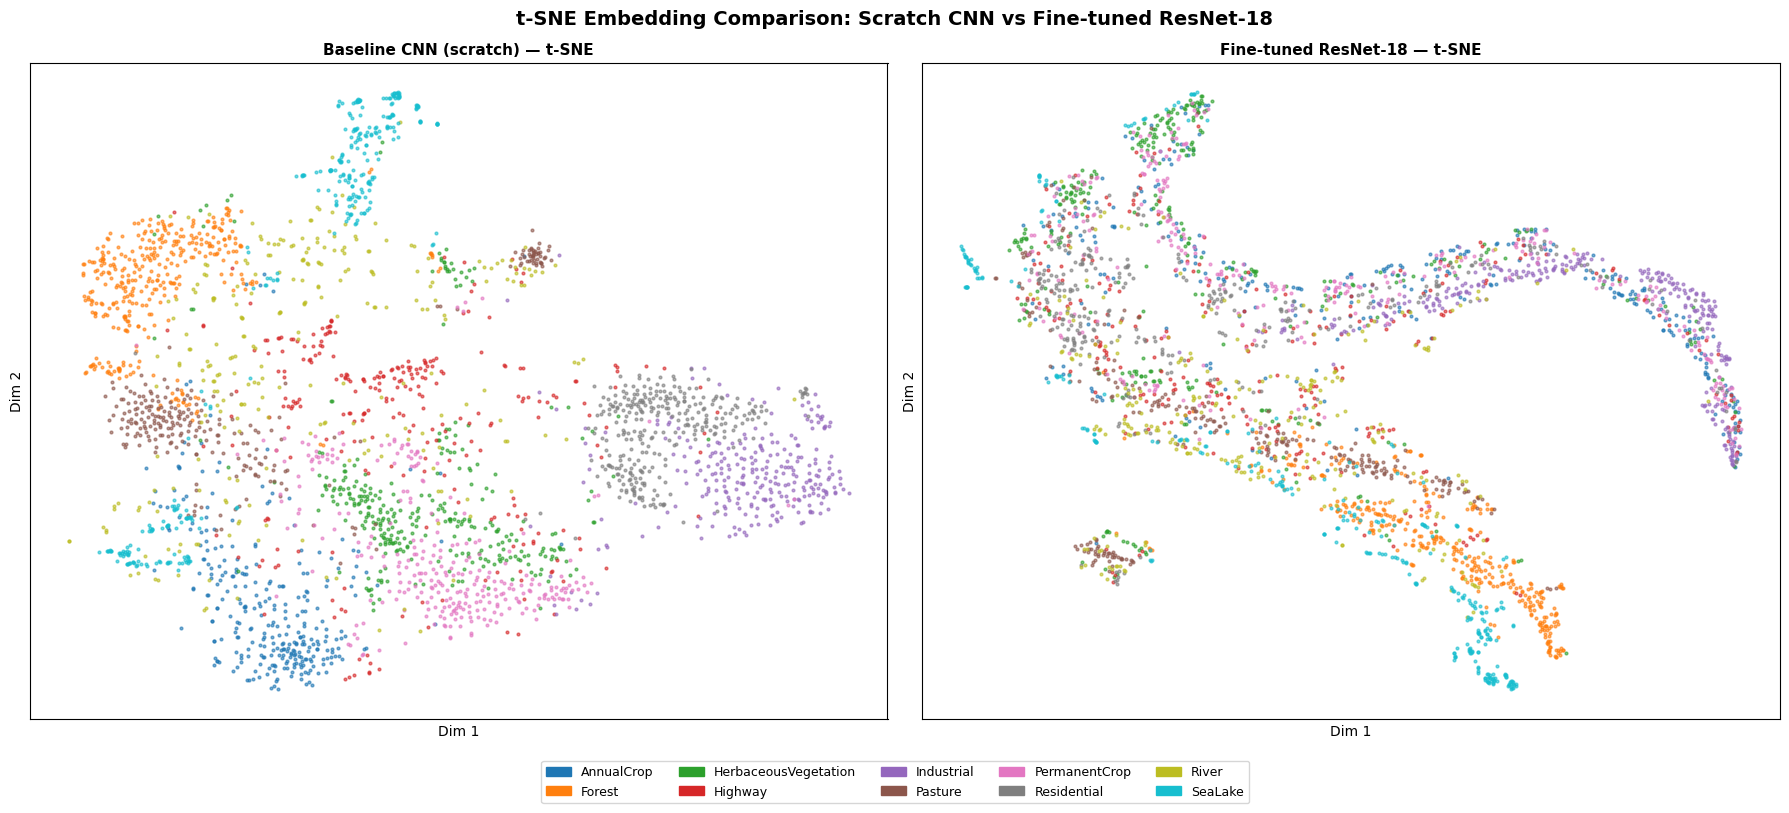

Saved: tsne_comparison.png


In [10]:
# ── t-SNE side-by-side plot ──────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('t-SNE Embedding Comparison: Scratch CNN vs Fine-tuned ResNet-18',
             fontsize=14, fontweight='bold')

scatter_2d(ax1, c_tsne, lbl_sub, 'Baseline CNN (scratch) — t-SNE')
scatter_2d(ax2, r_tsne, lbl_sub, 'Fine-tuned ResNet-18 — t-SNE')

fig.legend(handles=LEGEND, loc='lower center', ncol=5,
           fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(PLOTS_DIR / 'tsne_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: tsne_comparison.png')

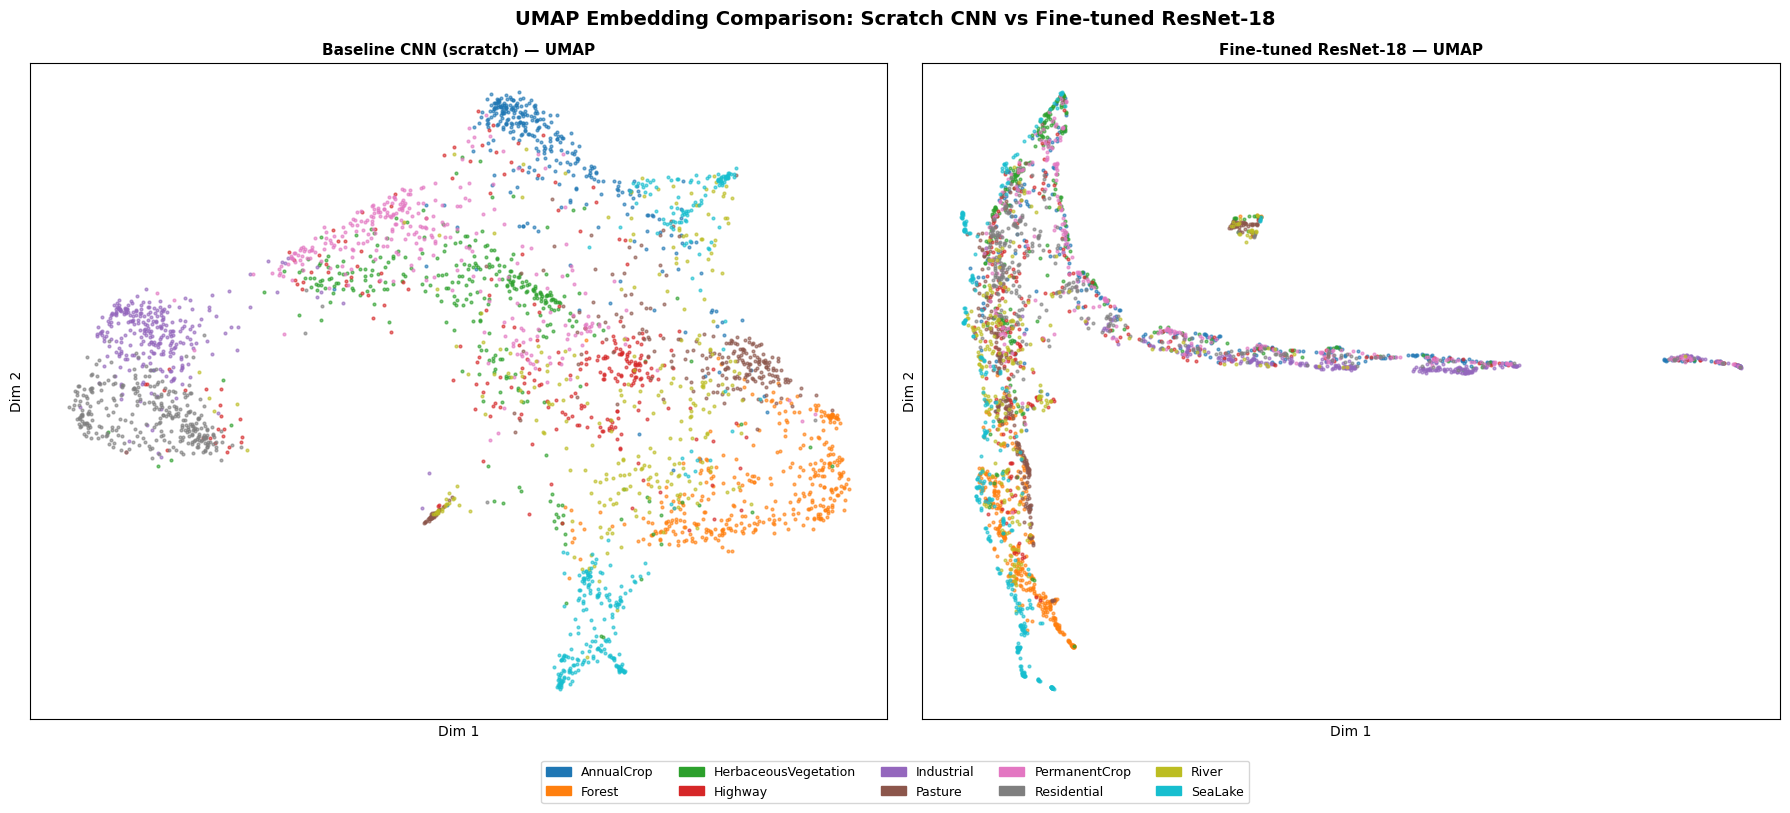

Saved: umap_comparison.png


In [11]:
# ── UMAP side-by-side plot ───────────────────────────────────────────────────
if UMAP_AVAILABLE:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
    fig.suptitle('UMAP Embedding Comparison: Scratch CNN vs Fine-tuned ResNet-18',
                 fontsize=14, fontweight='bold')

    scatter_2d(ax1, c_umap, lbl_sub, 'Baseline CNN (scratch) — UMAP')
    scatter_2d(ax2, r_umap, lbl_sub, 'Fine-tuned ResNet-18 — UMAP')

    fig.legend(handles=LEGEND, loc='lower center', ncol=5,
               fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig(PLOTS_DIR / 'umap_comparison.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('Saved: umap_comparison.png')
else:
    print('UMAP plot skipped (library not installed).')

In [13]:
# ── Cluster quality: intra/inter-class distance ratio ────────────────────────
from sklearn.metrics import silhouette_score

# t-SNE silhouette
sil_cnn    = silhouette_score(c_tsne, lbl_sub, sample_size=1000, random_state=42)
sil_resnet = silhouette_score(r_tsne, lbl_sub, sample_size=1000, random_state=42)

print('=== Embedding Quality (t-SNE 2D silhouette score) ===')
print(f'  Baseline CNN   : {sil_cnn:.4f}')
print(f'  ResNet-18 FT   : {sil_resnet:.4f}')
print()
print('Interpretation:')
print('  Higher silhouette score = more separated, more clustered embeddings.')
print('  Fine-tuned ResNet-18 should show clearly distinct class clusters,')
print('  while scratch CNN will show more overlap between similar land-use types.')

# Save for report
import json
with open(SRC_DIR / 'embedding_quality.json', 'w') as f:
    json.dump({'cnn_silhouette': float(sil_cnn), 'resnet_silhouette': float(sil_resnet)}, f, indent=2)
print('Saved embedding_quality.json')

=== Embedding Quality (t-SNE 2D silhouette score) ===
  Baseline CNN   : 0.1048
  ResNet-18 FT   : -0.1187

Interpretation:
  Higher silhouette score = more separated, more clustered embeddings.
  Fine-tuned ResNet-18 should show clearly distinct class clusters,
  while scratch CNN will show more overlap between similar land-use types.
Saved embedding_quality.json
